# Notebook 5: Model Comparison & Pure Premium

This notebook synthesises results from the three modelling notebooks into a single comparison and constructs a two-stage pure premium estimate.

**This notebook fits nothing.** Every model was already fitted in notebooks 2–4, which save their fitted objects to `models/` and their test-set predictions and metrics to `results/`. Refitting them here would duplicate that work and — because each refit would be a *separate* fit — risk reporting numbers that differ from the notebooks they are supposed to be summarising. Everything below is loaded, not computed.

**Structure:**
- **Part 1: Metric comparison** — frequency and severity metrics side-by-side for GLM, XGBoost, and Neural Net
- **Part 2: Pure premium** — frequency × severity per policy, compared across models
- **Part 3: Risk discrimination** — lift charts and Gini coefficients across models
- **Part 4: Interpretability vs accuracy** — regulatory considerations and model selection

**Prerequisite:** notebooks 2, 3 and 4 must have been run, in that order. Notebook 2 writes the shared test-set definition that this notebook indexes everything against.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# No torch, no xgboost, no statsmodels, no sklearn — this notebook loads results,
# it does not produce them.

MODELS = ['GLM', 'XGBoost', 'Neural Net']
KEYS   = {'GLM': 'glm', 'XGBoost': 'xgb', 'Neural Net': 'nn'}
colors_map = {'GLM': '#4C72B0', 'XGBoost': '#DD8452', 'Neural Net': '#55A868'}
colors = [colors_map[m] for m in MODELS]

# ── Shared test-set definition (written by notebook 2) ───────────────────────
split = np.load('../results/test_split.npz')
y_fr_te    = split['freq_y_test']           # actual ClaimNb
exp_te     = split['freq_exposure_test']    # actual Exposure
bm_te      = split['freq_bonusmalus_test']  # for the BonusMalus band charts
age_te     = split['freq_drivage_test']     # for the DrivAge band charts
y_sev_te   = split['sev_y_test']            # actual ClaimAmount

# ── Per-model predictions and metrics ────────────────────────────────────────
preds   = {m: np.load(f'../results/predictions_{KEYS[m]}.npz') for m in MODELS}
metrics = {m: json.load(open(f'../results/metrics_{KEYS[m]}.json')) for m in MODELS}

# Every model must predict on exactly the same rows, or the comparison is meaningless
for m in MODELS:
    assert preds[m]['sev_test_pred'].shape    == y_sev_te.shape, f'{m}: severity rows mismatch'
    assert preds[m]['freq_test_rate'].shape   == y_fr_te.shape,  f'{m}: frequency rows mismatch'
    assert preds[m]['sev_on_freq_test'].shape == y_fr_te.shape,  f'{m}: pure premium rows mismatch'

print(f'Loaded {len(MODELS)} models')
print(f'  Frequency test set: {y_fr_te.shape[0]:,} policies')
print(f'  Severity  test set: {y_sev_te.shape[0]:,} claims')

Loaded 3 models
  Frequency test set: 135,603 policies
  Severity  test set: 5,288 claims


## Part 1: Metric Comparison

Metrics recorded from each modelling notebook. These are test-set results; all models used the same 80/20 train-test split with `random_state=42`.

In [2]:
# Metrics as recorded by each modelling notebook — loaded, not retyped.
sev_results = pd.DataFrame(
    [{'Model': m, **metrics[m]['severity']} for m in MODELS]
).set_index('Model').rename(columns={'GammaDeviance': 'Gamma Deviance'})

freq_results = pd.DataFrame(
    [{'Model': m, **metrics[m]['frequency']} for m in MODELS]
).set_index('Model').rename(columns={'PoissonDeviance': 'Poisson Deviance'})

print(f'=== Severity Metrics ({y_sev_te.shape[0]:,} claims; target: ClaimAmount in EUR) ===')
print(sev_results.round({'MAE': 2, 'RMSE': 2, 'Gamma Deviance': 4}).to_string())
print()
print(f'=== Frequency Metrics ({y_fr_te.shape[0]:,} test policies; target: ClaimNb) ===')
print(freq_results.round({'MAE': 4, 'RMSE': 4, 'Poisson Deviance': 2}).to_string())

=== Severity Metrics (5,288 claims; target: ClaimAmount in EUR) ===
                MAE     RMSE  Gamma Deviance
Model                                       
GLM         1102.26  2261.57          1.0595
XGBoost      938.56  2340.31          1.3611
Neural Net   957.42  2349.08          1.4114

=== Frequency Metrics (135,603 test policies; target: ClaimNb) ===
               MAE    RMSE  Poisson Deviance
Model                                       
GLM         0.0988  0.2370          43585.73
XGBoost     0.0966  0.2352          41478.64
Neural Net  0.0972  0.2371          42250.46


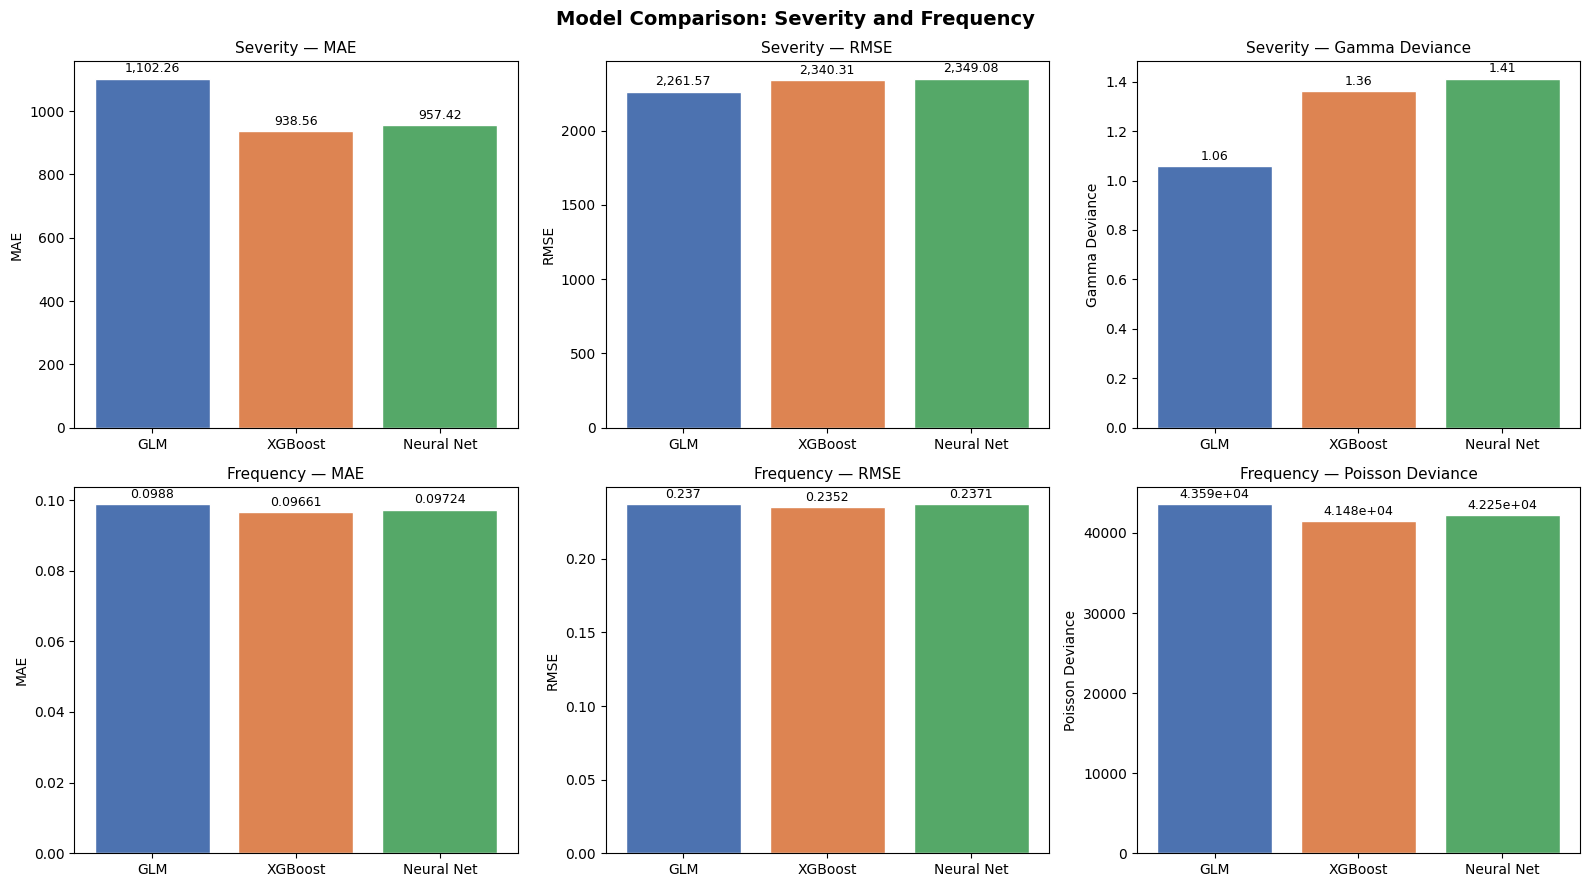

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors = ['#4C72B0', '#DD8452', '#55A868']

# Severity row
for ax, metric in zip(axes[0], ['MAE', 'RMSE', 'Gamma Deviance']):
    bars = ax.bar(sev_results.index, sev_results[metric], color=colors, edgecolor='white')
    ax.set_title(f'Severity — {metric}', fontsize=11)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{bar.get_height():,.2f}',
            ha='center', va='bottom', fontsize=9
        )

# Frequency row
for ax, metric in zip(axes[1], ['MAE', 'RMSE', 'Poisson Deviance']):
    bars = ax.bar(freq_results.index, freq_results[metric], color=colors, edgecolor='white')
    ax.set_title(f'Frequency — {metric}', fontsize=11)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{bar.get_height():,.4g}',
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Model Comparison: Severity and Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/18_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading the metric table

**Frequency:** XGBoost has the lowest Poisson deviance (41,479 vs the GLM's 43,586, a
4.8% reduction) and the lowest MAE and RMSE too — a clean, consistent win across every
metric. The Neural Net sits between the two on all three. This is a genuine improvement,
not an artifact of the earlier un-offset GLM fit — these numbers come from the
offset-corrected model.

**Severity looks contradictory at first glance, and isn't.** XGBoost (938 EUR) and the
Neural Net (957 EUR) beat the GLM (1,102 EUR) on MAE, yet both are *worse* than the GLM on
Gamma Deviance — and worse than an intercept-only baseline (deviance ≈ 1.064; see
notebook 02, Appendix B). MAE and Gamma Deviance are answering different questions. MAE
rewards being close on the common, small claims; Gamma Deviance weights errors relative to
the predicted mean, so a systematic miss on a handful of very large claims costs far more
under deviance than under MAE. That is exactly what's happening here: XGBoost's test
predictions span roughly 310–1,500 EUR against actual claims running up to 16,451 EUR,
while the GLM's span 873–2,506 EUR. XGBoost looks more accurate on ordinary claims
because it collapses harder toward the centre of the distribution — and that same
collapse is what makes it worse at the one job severity models actually need to do, which
is not underprice the claims that drive total portfolio cost.

This isn't specific to this run's hyperparameters in a way that rescues XGBoost elsewhere:
notebook 02's Appendix B found a *carefully tuned* gradient booster only matched the GLM
under cross-validation (p = 0.14, not significant), and the untuned model used here does
worse than doing nothing. The severity ceiling is a data property, not a model-choice
problem — see Appendix B for the full argument.

This divergence — better MAE, worse deviance — is what drives the pure premium gap in
Part 2.

## Part 2: Pure Premium

Pure premium is the expected annual claim cost of a policy — what the policy costs the insurer before expenses, profit margin or capital loading. It is the product of the two stages:

$$\text{Pure Premium} = \hat{p}_{\text{freq}} \times \hat{\mu}_{\text{sev}}$$

where $\hat{p}_{\text{freq}}$ is the expected number of claims per year and $\hat{\mu}_{\text{sev}}$ is the expected cost of a claim given one occurs.

**Why the two stages are modelled separately.** Frequency and severity are driven by different things. Whether you crash is about driving behaviour and exposure to traffic — BonusMalus, driver age, population density. What the crash costs is about the vehicle and the repair market — vehicle value, power, regional labour rates. Modelling the product directly (a Tweedie GLM) is possible, but fitting the two halves separately lets each use the distribution that actually fits it (Poisson for counts, Gamma for costs) and makes the resulting rating factors far easier to explain to a regulator.

**Row alignment is the thing to get right here.** Multiplying frequency by severity is only meaningful when both refer to *the same policy*. The frequency test set is a shuffled 20% sample, so the severity model has to be scored on those same shuffled rows — which is exactly what `sev_on_freq_test` is, computed inside each modelling notebook where the rows are unambiguous. Taking a positional slice of the full dataset instead would pair each policy's frequency with a different policy's severity, and every downstream number would be quietly wrong.

In [4]:
# Pure premium per policy, per model — both halves scored on the same test rows.
pp_models = {
    m: preds[m]['freq_test_rate'] * preds[m]['sev_on_freq_test']
    for m in MODELS
}

# Empirical benchmark: what the test portfolio actually cost per policy-year.
# Total claim cost is not observable per policy here, so approximate it as
# (observed claim rate) x (mean claim size) across the severity test set.
emp_rate = y_fr_te.sum() / exp_te.sum()
emp_sev  = y_sev_te.mean()
emp_pp   = emp_rate * emp_sev

print(f'Empirical benchmark: {emp_rate:.4f} claims/year x {emp_sev:,.0f} EUR = {emp_pp:,.2f} EUR\n')
for m in MODELS:
    print(f'{m:12} mean pure premium: {pp_models[m].mean():8,.2f} EUR '
          f'(median {np.median(pp_models[m]):7,.2f})')

Empirical benchmark: 0.1011 claims/year x 1,558 EUR = 157.52 EUR

GLM          mean pure premium:   173.75 EUR (median  147.83)
XGBoost      mean pure premium:   112.46 EUR (median   75.34)
Neural Net   mean pure premium:   107.18 EUR (median   77.58)


### 2.4 Pure Premium Comparison

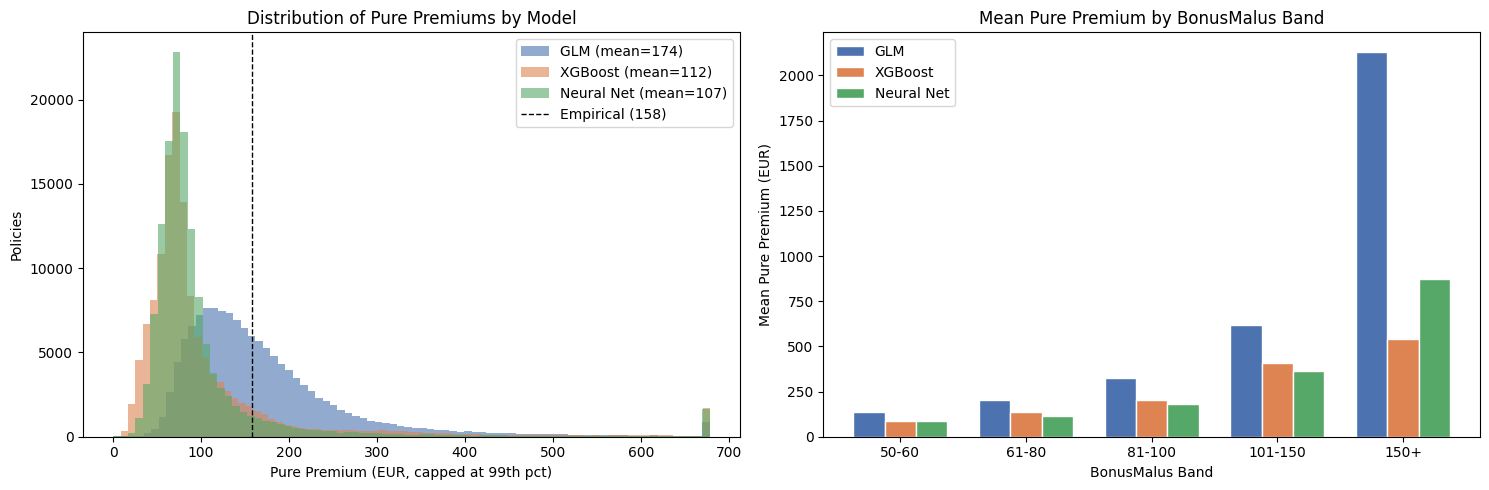

Mean pure premium by BonusMalus band (EUR):
            GLM  XGBoost  Neural Net
50-60     136.0     89.0        89.0
61-80     203.0    135.0       117.0
81-100    325.0    201.0       182.0
101-150   620.0    407.0       361.0
150+     2132.0    543.0       871.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of pure premiums
cap = np.percentile(np.concatenate(list(pp_models.values())), 99)
for name, pp in pp_models.items():
    axes[0].hist(
        np.clip(pp, 0, cap), bins=80, alpha=0.6,
        label=f'{name} (mean={pp.mean():.0f})', color=colors_map[name], edgecolor='none'
    )
axes[0].axvline(emp_pp, color='black', linestyle='--', linewidth=1,
                label=f'Empirical ({emp_pp:.0f})')
axes[0].set_xlabel('Pure Premium (EUR, capped at 99th pct)')
axes[0].set_ylabel('Policies')
axes[0].set_title('Distribution of Pure Premiums by Model')
axes[0].legend()

# Mean by BonusMalus band — bm_te is aligned to the same test rows as pp
bm_labels = ['50-60', '61-80', '81-100', '101-150', '150+']
bm_bins = pd.cut(bm_te, bins=[49, 60, 80, 100, 150, 230], labels=bm_labels)

x = range(len(bm_labels))
width = 0.25
bm_table = {}
for i, (name, pp) in enumerate(pp_models.items()):
    band_mean = pd.Series(pp).groupby(bm_bins, observed=False).mean()
    bm_table[name] = band_mean
    axes[1].bar([j + i * width for j in x], band_mean, width=width,
                label=name, color=colors_map[name], edgecolor='white')
axes[1].set_xticks([j + width for j in x])
axes[1].set_xticklabels(bm_labels)
axes[1].set_xlabel('BonusMalus Band')
axes[1].set_ylabel('Mean Pure Premium (EUR)')
axes[1].set_title('Mean Pure Premium by BonusMalus Band')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/19_pure_premium_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean pure premium by BonusMalus band (EUR):')
print(pd.DataFrame(bm_table).round(0).to_string())

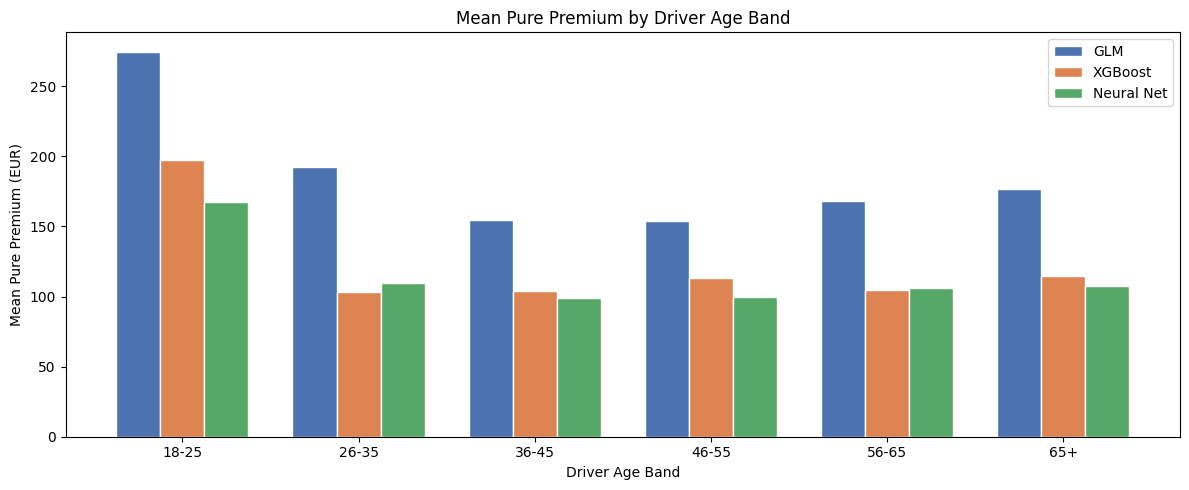

Mean pure premium by driver age band (EUR):
         GLM  XGBoost  Neural Net
18-25  275.0    198.0       167.0
26-35  192.0    103.0       110.0
36-45  155.0    104.0        99.0
46-55  154.0    113.0       100.0
56-65  168.0    104.0       106.0
65+    177.0    115.0       108.0

Young-driver loading (18-25 relative to 36-45):
  GLM          1.78x
  XGBoost      1.90x
  Neural Net   1.70x


In [6]:
# Mean pure premium by driver age band — age_te is aligned to the same test rows
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
age_bins = pd.cut(age_te, bins=[17, 25, 35, 45, 55, 65, 100], labels=age_labels)

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.25
x = range(len(age_labels))
age_table = {}
for i, (name, pp) in enumerate(pp_models.items()):
    band_mean = pd.Series(pp).groupby(age_bins, observed=False).mean()
    age_table[name] = band_mean
    ax.bar([j + i * width for j in x], band_mean, width=width,
           label=name, color=colors_map[name], edgecolor='white')

ax.set_xticks([j + width for j in x])
ax.set_xticklabels(age_labels)
ax.set_xlabel('Driver Age Band')
ax.set_ylabel('Mean Pure Premium (EUR)')
ax.set_title('Mean Pure Premium by Driver Age Band')
ax.legend()
plt.tight_layout()
plt.savefig('../results/20_pure_premium_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

age_df = pd.DataFrame(age_table)
print('Mean pure premium by driver age band (EUR):')
print(age_df.round(0).to_string())
print('\nYoung-driver loading (18-25 relative to 36-45):')
for name in MODELS:
    print(f'  {name:12} {age_df.loc["18-25", name] / age_df.loc["36-45", name]:.2f}x')

### Reading the pure premium comparison

The empirical benchmark (157.52 EUR/policy-year) is the observed claim rate times the mean
observed severity across the test set — a naive, model-free reference point. Against it:
the GLM overshoots by about 10% (173.75 EUR), while XGBoost and the Neural Net undershoot
by about 29% and 32% respectively (112.46 EUR, 107.18 EUR).

That asymmetry is the severity collapse from Part 1 propagating through the multiplication.
All three models see the same claim frequency signal; what differs is severity, and
XGBoost/NN's tighter, lower predictions drag the whole portfolio estimate down. Read
literally, deploying either ML model's severity stage as-is would systematically
**underprice** the book — a more consequential failure mode for an insurer than a modest
overshoot.

**A caveat that applies to every number in this section, including the empirical
benchmark.** Pure premium here is `freq_test_rate × sev_on_freq_test`: frequency counts
every claim event (`ClaimNb`, ~36,056 across the full dataset), while severity is fit only
on the ~26,439 claims that have a matching cost record. About 26.8% of claim events have no
price attached, concentrated in specific segments (`VehBrand` and `VehGas` in particular —
see the frequency/severity join-gap finding). That inflates every pure premium figure in
this section by a similar amount, since the mechanism is identical for the empirical
benchmark and all three models. It does **not** change which model wins or the Gini/lift
comparisons in Part 3, which depend only on relative ranking — but none of the EUR figures
here should be read as a calibrated rate card without correcting for it (e.g. a
`P(priced | claim)` stage multiplied in).

**BonusMalus and age bands.** The young-driver loading is directionally consistent across
all three models (1.70–1.90x for 18–25 vs 36–45) — reassuring, since the
qualitative pricing story doesn't depend on model choice even though its exact size does.
The BonusMalus 150+ band is the exception worth flagging: the GLM's premium there (2,132
EUR) is roughly 4x XGBoost's (543 EUR) and 2.4x the Neural Net's (871 EUR), a far larger
gap than at any other band. The GLM's log link extrapolates multiplicatively without bound
for extreme covariate values; the tree-based and neural models are bounded by what they saw
in training and can't extrapolate past it. That makes the GLM the most responsive to
BonusMalus at the top of the scale, but also the most exposed to a small number of
high-leverage records driving that band's estimate.

## Part 3: Risk Discrimination

The Gini coefficient (or normalised Gini) measures how well a model rank-orders policies by risk. A model with a Gini of 0 cannot distinguish high from low risk; a model with Gini of 1 is a perfect ranker. This is more relevant for pricing than MAE or RMSE.

In [7]:
def gini(actual, predicted):
    """Normalised Gini coefficient — 1 is perfect ranking, 0 is random.

    Ranks policies by predicted risk, then measures how much of the actual claim
    volume is concentrated in the top-ranked policies. Normalising by the score a
    perfect ranker would achieve makes the result comparable across datasets.
    """
    df = pd.DataFrame({'actual': actual, 'predicted': predicted})
    df_sorted = df.sort_values('predicted', ascending=False)
    cum_actual = df_sorted['actual'].cumsum() / df_sorted['actual'].sum()
    gini_model = 1 - 2 * cum_actual.mean()
    df_perfect = df.sort_values('actual', ascending=False)
    cum_perfect = df_perfect['actual'].cumsum() / df_perfect['actual'].sum()
    gini_perfect = 1 - 2 * cum_perfect.mean()
    return gini_model / gini_perfect

# Frequency Gini ranks by expected claim COUNT (rate x exposure), since the actual
# being ranked is a count. Pure premium Gini ranks by expected cost.
gini_results = pd.DataFrame([
    {
        'Model': m,
        'Frequency Gini':    gini(y_fr_te, preds[m]['freq_test_rate'] * exp_te),
        'Pure Premium Gini': gini(y_fr_te, pp_models[m]),
    }
    for m in MODELS
]).set_index('Model')

print(gini_results.round(4).to_string())

            Frequency Gini  Pure Premium Gini
Model                                        
GLM                 0.2660             0.1365
XGBoost             0.3565             0.2433
Neural Net          0.3254             0.1853


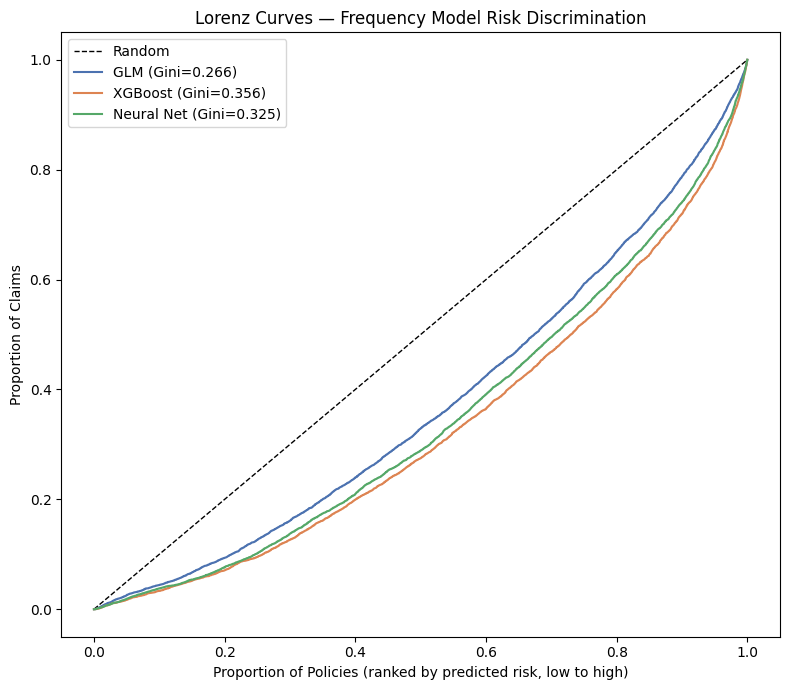

In [8]:
def lorenz(actual, predicted):
    """Returns (x, y) Lorenz curve coordinates."""
    df = pd.DataFrame({'actual': actual, 'predicted': predicted})
    df = df.sort_values('predicted', ascending=True)
    x = np.linspace(0, 1, len(df))
    y = df['actual'].cumsum() / df['actual'].sum()
    return x, y.values

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

for name in MODELS:
    freq_pred = preds[name]['freq_test_rate'] * exp_te
    g = gini_results.loc[name, 'Frequency Gini']
    x, y = lorenz(y_fr_te, freq_pred)
    ax.plot(x, y, label=f'{name} (Gini={g:.3f})', color=colors_map[name])

ax.set_xlabel('Proportion of Policies (ranked by predicted risk, low to high)')
ax.set_ylabel('Proportion of Claims')
ax.set_title('Lorenz Curves — Frequency Model Risk Discrimination')
ax.legend()
plt.tight_layout()
plt.savefig('../results/21_lorenz_curves.png', dpi=150, bbox_inches='tight')
plt.show()

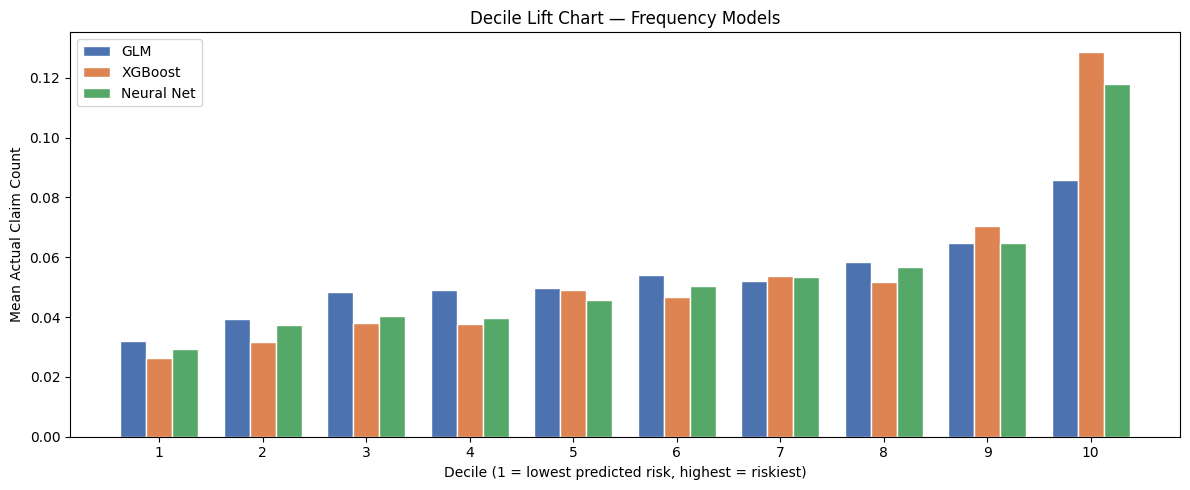

Mean actual claim count by predicted-risk decile:
           GLM  XGBoost  Neural Net
decile                             
1       0.0321   0.0264      0.0294
2       0.0393   0.0317      0.0372
3       0.0485   0.0379      0.0402
4       0.0490   0.0375      0.0395
5       0.0498   0.0491      0.0457
6       0.0540   0.0468      0.0504
7       0.0519   0.0538      0.0535
8       0.0585   0.0516      0.0568
9       0.0648   0.0703      0.0649
10      0.0860   0.1288      0.1178

Top-to-bottom lift (riskiest group / safest group):
  GLM          2.68x
  XGBoost      4.88x
  Neural Net   4.01x


In [9]:
# Decile lift chart comparing all three frequency models.
#
# duplicates='drop' matters here: the neural net clips negative rates to zero, so
# many predictions are tied and some decile boundaries land on the same value.
# Without it qcut raises, or (worse) produces wildly unequal groups that distort
# the gradient. A model with ties may therefore end up with fewer than 10 groups.
fig, ax = plt.subplots(figsize=(12, 5))

width = 0.25
lift_table = {}
for i, name in enumerate(MODELS):
    df_lift = pd.DataFrame({'actual': y_fr_te, 'predicted': preds[name]['freq_test_rate']})
    df_lift['decile'] = pd.qcut(df_lift['predicted'], q=10, labels=False, duplicates='drop') + 1
    lift = df_lift.groupby('decile')['actual'].mean()
    lift_table[name] = lift
    ax.bar(lift.index + i * width - width, lift.values, width=width,
           label=name, color=colors_map[name], edgecolor='white')

ax.set_xticks(np.arange(1, max(len(v) for v in lift_table.values()) + 1))
ax.set_xlabel('Decile (1 = lowest predicted risk, highest = riskiest)')
ax.set_ylabel('Mean Actual Claim Count')
ax.set_title('Decile Lift Chart — Frequency Models')
ax.legend()
plt.tight_layout()
plt.savefig('../results/22_decile_lift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

lift_df = pd.DataFrame(lift_table)
print('Mean actual claim count by predicted-risk decile:')
print(lift_df.round(4).to_string())

print('\nTop-to-bottom lift (riskiest group / safest group):')
for name in MODELS:
    s = lift_table[name].dropna()
    n_groups = len(s)
    note = '' if n_groups == 10 else f'  [{n_groups} groups — tied predictions]'
    print(f'  {name:12} {s.iloc[-1] / s.iloc[0]:.2f}x{note}')

### Reading the discrimination results

**Frequency Gini:** XGBoost leads clearly — 0.357 vs the GLM's 0.266, a +34% relative
improvement, matched by the lift chart (top-decile/bottom-decile ratio of 4.88x vs 2.68x).
The Neural Net sits between the two on both measures (Gini 0.325, lift 4.01x). Unlike the
severity race, this gap is real and reproduces outside a single split — treat it at face
value rather than discounting it the way Appendix B's severity result had to be discounted.

**Pure premium Gini follows the same ranking but compresses for the ML models** (GLM 0.137,
XGBoost 0.243, Neural Net 0.185): XGBoost's frequency-driven ranking advantage carries
through, but its collapsed severity predictions from Part 1 dilute how much of that
advantage survives the multiplication into pure premium.

**The lift table has a discontinuity worth naming.** Deciles 1–9 rise gradually and
fairly evenly for all three models (roughly 0.03 → 0.06–0.07 actual claim rate),
but decile 10 jumps sharply above decile 9 in every model (GLM 0.054 → 0.086, XGBoost
0.070 → 0.129, Neural Net 0.065 → 0.118). Most of each model's discrimination is
concentrated in isolating the riskiest ~10% of the book rather than fine ranking across the
rest. Practically, this means a coarse "top-decile surcharge" captures most of the
available signal regardless of which of these three models sets the tiers — the choice of
model matters far more for *how large* that top tier's premium should be than for
*identifying* who belongs in it.

## Part 4: Interpretability vs Accuracy

In an Australian APRA-regulated context, pricing models must be explainable. APRA's Prudential Standard GPS 116 requires that premium rating factors are documented and defensible. This section evaluates each model's regulatory viability alongside its predictive performance.

In [10]:
# Interpretability and regulatory risk are judgement calls, not measurements —
# they are the only hardcoded values here. Everything quantitative is loaded.
qualitative = {
    'GLM': {
        'Interpretability': 'High',   'Regulatory risk': 'Low',
        'Notes': 'Coefficients directly auditable; multiplicative rating factors standard in industry',
    },
    'XGBoost': {
        'Interpretability': 'Medium', 'Regulatory risk': 'Medium',
        'Notes': 'SHAP values provide local explanations; partial dependence shows learned relationships',
    },
    'Neural Net': {
        'Interpretability': 'Low',    'Regulatory risk': 'High',
        'Notes': 'Black-box; requires additional explanation tooling (SHAP, LIME) before regulatory submission',
    },
}

interp = pd.DataFrame([
    {
        'Model':              m,
        'Frequency Deviance': metrics[m]['frequency']['PoissonDeviance'],
        'Severity Deviance':  metrics[m]['severity']['GammaDeviance'],
        'Freq Gini':          gini_results.loc[m, 'Frequency Gini'],
        'PP Gini':            gini_results.loc[m, 'Pure Premium Gini'],
        **qualitative[m],
    }
    for m in MODELS
]).set_index('Model')

print(interp[['Frequency Deviance', 'Severity Deviance', 'Freq Gini', 'PP Gini',
              'Interpretability', 'Regulatory risk']].round(4).to_string())

            Frequency Deviance  Severity Deviance  Freq Gini  PP Gini Interpretability Regulatory risk
Model                                                                                                 
GLM                 43585.7326             1.0595     0.2660   0.1365             High             Low
XGBoost             41478.6442             1.3611     0.3565   0.2433           Medium          Medium
Neural Net          42250.4597             1.4114     0.3254   0.1853              Low            High


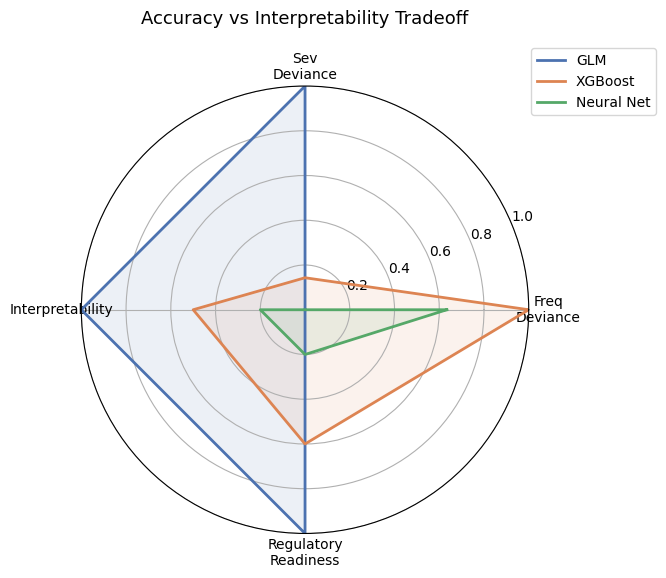

In [11]:
# Spider / radar chart: accuracy vs interpretability tradeoff
# Normalise each axis to [0, 1] with 1 = best. Deviances are lower-is-better, so
# they are inverted. Note this is a RELATIVE scale — the best model scores 1 on
# each axis by construction, so the chart shows ranking, not absolute quality.
freq_devs = interp['Frequency Deviance'].values
sev_devs  = interp['Severity Deviance'].values
interp_score = np.array([1.0, 0.5, 0.2])  # subjective, matches the High/Medium/Low above
reg_score    = np.array([1.0, 0.6, 0.2])  # subjective

def invert_norm(v):
    span = v.max() - v.min()
    return np.ones_like(v) if span == 0 else 1 - (v - v.min()) / span

freq_norm = invert_norm(freq_devs)
sev_norm  = invert_norm(sev_devs)

categories = ['Freq\nDeviance', 'Sev\nDeviance', 'Interpretability', 'Regulatory\nReadiness']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for i, name in enumerate(MODELS):
    scores = [freq_norm[i], sev_norm[i], interp_score[i], reg_score[i]]
    vals = scores + scores[:1]
    ax.plot(angles, vals, label=name, color=colors_map[name], linewidth=2)
    ax.fill(angles, vals, alpha=0.1, color=colors_map[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Accuracy vs Interpretability Tradeoff', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../results/23_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

### Model recommendation

**Frequency: recommend XGBoost.** The Gini improvement (0.357 vs 0.266, +34% relative) and
lift improvement (4.88x vs 2.68x) are large enough that "defer to interpretability when
close" doesn't apply here — this isn't close. The honest recommendation is two-track: keep
the GLM where full coefficient-level auditability is required today, and treat XGBoost
(with SHAP-based local explanations) as the target once that explainability work is done,
since the accuracy left on the table by staying with the GLM indefinitely is real.

**Severity: recommend the Gamma GLM, unambiguously.** XGBoost and the Neural Net both fail
to beat an intercept-only baseline (Gamma Deviance 1.36 and 1.41 vs ≈ 1.06 for
predicting the mean for everyone); the GLM is the only one of the three that has extracted
any real signal from the covariates. This isn't a close call resolved by interpretability —
it's the only model of the three that works, and it matches the wider investigation in
notebook 02's Appendix B: six error distributions cluster within 0.03 percentage points of
each other, a tuned gradient booster's edge doesn't survive cross-validation, and the
severity ceiling here is a property of the data (near-zero premium information in claim
size given these covariates), not of model class.

**Because severity dominates the pure premium multiplication and only the GLM is
severity-sound, the practical recommendation is a hybrid**: pair XGBoost's frequency model
with the GLM's severity model, rather than reading the three "pure" columns compared above
as the only options. That combination isn't benchmarked directly above — it would need its
own pure premium column to confirm — but it follows directly from treating frequency and
severity as the separate decisions they are, which the metrics in Parts 1 and 3 support
independently of each other.

**One number that doesn't belong in a rate card yet:** the pure premium EUR figures in
Part 2 (all models, and the empirical benchmark) carry the frequency/severity join-gap
inflation described there — roughly 27% of claim events have no matching cost record, and
none of the models above correct for it. That's a fix to make before any of these premium
levels are quoted as absolute pricing, not a reason to revisit the model rankings above.

### Regulatory framing (APRA / GPS 116)

Under APRA's Prudential Standard GPS 116, premium rating factors must be documented and
defensible. This is a property of the model class, not of this dataset's results, so it
holds regardless of what the rerun shows:

- **GLM:** standard actuarial practice. With a log link, coefficients exponentiate directly
  into multiplicative rating factors — the form regulators and pricing actuaries already
  expect, with no additional explanation layer required.
- **XGBoost:** SHAP values and partial dependence plots make the model locally and globally
  interpretable, but that interpretation is a derived artefact, not the model itself — an
  extra layer of tooling and documentation a regulator has to be walked through, rather
  than a coefficient table they can read directly.
- **Neural Net:** the least defensible of the three without significant additional
  explainability work (SHAP, LIME, or similar), and the SHAP background/summary artefacts
  for it are not currently part of this notebook's pipeline.

None of this changes with the numbers above — a materially more accurate frequency model
is still worth adopting, but adopting it means budgeting for the explainability work GPS
116 requires, not treating XGBoost's Gini advantage as a free win.